# MediBot — Adaptive RAG Development Notebook

End-to-end notebook: PDF ingestion → Pinecone indexing → Adaptive RAG with LangGraph.


#  1. Environment Setup

In [3]:
%pwd

'c:\\Users\\ADMIN\\Desktop\\Data_Science\\Projects\\End2End-MediBot\\End2End-MediBot'

In [2]:
%cd ..

c:\Users\ADMIN\Desktop\Data_Science\Projects\End2End-MediBot\End2End-MediBot


In [4]:
from dotenv import load_dotenv
import os

load_dotenv()


True

In [5]:
PINECONE_API_KEY = os.getenv("PINECONE_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")


os.environ["PINECONE_API_KEY"] = PINECONE_API_KEY
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

In [6]:
TAVILY_API_KEY   = os.getenv("TAVILY_API_KEY")
os.environ["TAVILY_API_KEY"]   = TAVILY_API_KEY

## 2. PDF Loading & Chunking

In [7]:
from langchain_community.document_loaders import PyPDFLoader, DirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing import List
from langchain_core.documents import Document

c:\ProgramData\anaconda3\envs\medibot\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
def load_pdf_files(data):
    """Load all PDFs from a directory."""
    loader = DirectoryLoader(
        data,
        glob="*.pdf",
        loader_cls=PyPDFLoader
    )
    return loader.load()


def filter_to_minimal_docs(docs: List[Document]) -> List[Document]:
    """Strip metadata down to just 'source' to keep Pinecone payloads lean."""
    return [
        Document(
            page_content=doc.page_content,
            metadata={"source": doc.metadata.get("source")}
        )
        for doc in docs
    ]


def text_split(docs: List[Document]) -> List[Document]:
    """Split documents into 500-token chunks with 20-token overlap."""
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,
        chunk_overlap=20,
    )
    return splitter.split_documents(docs)


print("Document utility functions defined")

Document utility functions defined


In [9]:
extracted_docs = load_pdf_files("data")
print(f"Loaded {len(extracted_docs)} pages")

Loaded 637 pages


In [10]:
minimal_docs = filter_to_minimal_docs(extracted_docs)
texts_chunk  = text_split(minimal_docs)
print(f"Total chunks: {len(texts_chunk)}")
texts_chunk[0]  # preview first chunk

Total chunks: 5859


Document(metadata={'source': 'data\\Medical_book.pdf'}, page_content='The GALE\nENCYCLOPEDIA\nof MEDICINE\nSECOND EDITION')

## 3. Embeddings & Pinecone Indexing

In [11]:
from langchain_huggingface import HuggingFaceEmbeddings

def download_embeddings():
    """Load sentence-transformers/all-MiniLM-L6-v2 (384-dim)."""
    return HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

embeddings = download_embeddings()

# Quick sanity check
vector = embeddings.embed_query("Hello world")
print(f"Embeddings loaded — vector dim: {len(vector)}")

c:\ProgramData\anaconda3\envs\medibot\lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Embeddings loaded — vector dim: 384


In [12]:
from pinecone import Pinecone, ServerlessSpec

pc         = Pinecone(api_key=PINECONE_API_KEY)
index_name = "medibot"

if index_name not in [idx.name for idx in pc.list_indexes()]:
    pc.create_index(
        name      = index_name,
        dimension = 384,
        metric    = "cosine",
        spec      = ServerlessSpec(cloud="aws", region="us-east-1")
    )
    print(f" Created Pinecone index: '{index_name}'")
else:
    print(f" Index '{index_name}' already exists")

index = pc.Index(index_name)
index.describe_index_stats()

 Index 'medibot' already exists


{'dimension': 384,
 'index_fullness': 0.0,
 'namespaces': {'': {'vector_count': 5859}},
 'total_vector_count': 5859}

In [ ]:
from langchain_pinecone import PineconeVectorStore

#  Upsert new documents (run once after PDF ingestion)


docsearch = PineconeVectorStore.from_documents(
     documents  = texts_chunk,
     embedding  = embeddings,
     index_name = index_name
 )

print(" Documents upserted into Pinecone")


In [14]:
# Load existing index 
docsearch = PineconeVectorStore.from_existing_index(
    index_name = index_name,
    embedding  = embeddings
)

retriever = docsearch.as_retriever(search_type="similarity", search_kwargs={"k": 3})

# Quick test
test_docs = retriever.invoke("What is Acne?")
print(f"Retriever ready — test query returned {len(test_docs)} docs")
test_docs[0]

Retriever ready — test query returned 3 docs


Document(id='35d4c938-fdd6-437f-979d-00e0e4d9b3e3', metadata={'source': 'data\\Medical_book.pdf'}, page_content='GALE ENCYCLOPEDIA OF MEDICINE 226\nAcne\nGEM - 0001 to 0432 - A  10/22/03 1:41 PM  Page 26')

## 4. Adaptive RAG Components


In [20]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel, Field
from typing import Literal

# Shared LLM 
llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)
print("Groq LLM ready")

Groq LLM ready


In [21]:
llm.invoke("Hello world")

AIMessage(content='Hello world. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 37, 'total_tokens': 48, 'completion_time': 0.020371066, 'prompt_time': 0.005329577, 'queue_time': 0.053176503, 'total_time': 0.025700643}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019de2f7-fc10-7841-8a7f-fb9b9838eb12-0', usage_metadata={'input_tokens': 37, 'output_tokens': 11, 'total_tokens': 48})

### 4a. Router
Decides whether to answer from the **Pinecone vectorstore** or fall back to **web search**.

In [43]:
class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource."""
    datasource: Literal["vectorstore", "web_search"] = Field(
        description="'vectorstore' for medical KB queries, 'web_search' for recent/unknown topics."
    )

router_prompt = ChatPromptTemplate.from_messages([
    ("system",
     """You are an expert at routing a user question to the right datasource.

The vectorstore contains medical knowledge: diseases, symptoms, treatments, medications,
anatomy, pharmacology, and general health information.

Route to 'vectorstore' for medical/health questions answerable from a medical reference.
Route to 'web_search' for recent medical news, non-medical questions, or  any health topic that may not be in the medical reference 
(e.g. sexual health, lifestyle questions, mental health, emerging treatments)

Return ONLY the routing decision."""),
    ("human", "{question}"),
])

question_router = router_prompt | llm.with_structured_output(RouteQuery)

# Test
print(question_router.invoke({"question": "What are the effects of cancer?"}))
print(question_router.invoke({"question": "Latest FDA drug approvals 2025?"}))

datasource='vectorstore'
datasource='web_search'


### 4b. Retrieval Grader
Filters out irrelevant retrieved documents before passing them to the generator.

In [44]:
class GradeDocuments(BaseModel):
    """Binary relevance score for a retrieved document."""
    binary_score: str = Field(description="'yes' if relevant, 'no' if not.")

grade_prompt = ChatPromptTemplate.from_messages([
    ("system",
     """You are a grader assessing the relevance of a retrieved medical document to a user question.
If the document contains keywords or semantic meaning related to the question, grade it as relevant.
This is not a strict test — just filter clearly irrelevant retrievals.
Return your answer ONLY as a JSON object with this format:
{{
  "binary_score": "yes" or "no"
}}
Do not explain anything.
"""),
    ("human", "Retrieved document:\n\n{document}\n\nUser question: {question}"),
])

retrieval_grader = grade_prompt | llm.with_structured_output(GradeDocuments)

# Test
question  = "What is Acne?"
docs      = retriever.invoke(question)
doc_txt   = docs[0].page_content
print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

binary_score='yes'


### 4c. RAG Generation Chain

In [45]:
system_prompt = (
    "You are a Medical assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer the question. "
    "If you don't know the answer, say that you don't know. "
    "Use three sentences maximum and keep the answer concise."
    "\n\n{context}"
)

rag_prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{question}"),
])

rag_chain = rag_prompt | llm | StrOutputParser()

# Test
generation = rag_chain.invoke({"context": docs, "question": question})
print(generation)

Acne is a common skin disease characterized by pimples on the face, chest, and back. It occurs when the pores of the skin become clogged with oil, dead skin cells, and bacteria. Acne vulgaris is the medical term for common acne.


### 4d. Hallucination Grader
Checks whether the generated answer is grounded in the retrieved documents.

In [27]:
class GradeHallucinations(BaseModel):
    """Binary score — is the generation grounded in the facts?"""
    binary_score: str = Field(description="'yes' if grounded, 'no' if hallucinated.")

hallucination_prompt = ChatPromptTemplate.from_messages([
    ("system",
     """You are a grader checking whether an LLM medical answer is grounded in the source documents.
'yes' = answer is supported. 'no' = answer contains hallucinations. Be strict — patient safety matters."""),
    ("human", "Source documents:\n\n{documents}\n\nLLM answer: {generation}"),
])

hallucination_grader = hallucination_prompt | llm.with_structured_output(GradeHallucinations)

print(hallucination_grader.invoke({"documents": docs, "generation": generation}))

binary_score='yes'


### 4e. Answer Grader
Checks whether the answer actually resolves the user's question.

In [46]:
class GradeAnswer(BaseModel):
    """Binary score — does the answer resolve the question?"""
    binary_score: str = Field(description="'yes' if resolved, 'no' if not.")

answer_prompt = ChatPromptTemplate.from_messages([
    ("system",
     """You are a grader assessing whether a medical answer resolves the user's question.
'yes' = directly addresses the question. 'no' = off-topic, incomplete, or missing."""),
    ("human", "User question:\n\n{question}\n\nLLM answer: {generation}"),
])

answer_grader = answer_prompt | llm.with_structured_output(GradeAnswer)

print(answer_grader.invoke({"question": question, "generation": generation}))

binary_score='yes'


### 4f. Query Rewriter
Rewrites the question for better vectorstore retrieval when initial docs are irrelevant.

In [47]:
rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system",
     """You are a query optimizer for a medical vectorstore retrieval system.
Rewrite the input question into a cleaner, more precise version that retrieves better results.
Focus on the core medical concept. Remove conversational filler.
Return ONLY the improved question."""),
    ("human", "Original question:\n\n{question}\n\nImproved question:"),
])

question_rewriter = rewrite_prompt | llm | StrOutputParser()

print(question_rewriter.invoke({"question": "my head hurts a lot what could be wrong?"}))

What are the possible causes of severe headache?


### 4g. Web Search Tool (Tavily fallback)

In [30]:
from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults(k=3)

# Test
results = web_search_tool.invoke({"query": "latest FDA drug approval 2025"})
print(results[0]["content"][:300])

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4088\1143387509.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(k=3)


drugs approved in 2025 with orphan drug designation were: Andembry; Avmapki Fakzynja; Dawnzera; Ekterly; Forzinity; Gomekli; Grafapex; Hyrnuo; Ibtrozi; Imaavy; Jascayd; Komzifti; Kygevvi; Lynozyfic; Modeyso; Myqorzo; Palsonify; penpulimab-kcqx Qfitlia; Redemplo; Sephience; Wayrilz; Yartemlea Approve


## 5. LangGraph Adaptive RAG Pipeline

Wires all components into a stateful graph with conditional routing.

In [48]:
from typing import List
from typing_extensions import TypedDict
from langchain_core.documents import Document
from langgraph.graph import END, StateGraph, START

class GraphState(TypedDict):
    question:   str
    generation: str
    documents:  List[Document]
    retries:    int 
    rewrite_count: int

print("GraphState defined")

GraphState defined


In [49]:
def grade_generation(state: GraphState) -> str:
    print("---GRADING GENERATION---")
    question   = state["question"]
    documents  = state["documents"]
    generation = state["generation"]
    retries    = state.get("retries", 0)

    # After 2 failed attempts, fall back to web search
    if retries >= 2:
        print("  → Max retries reached, falling back to web search")
        return "not useful"

    h_score = hallucination_grader.invoke({"documents": documents, "generation": generation})
    h_grade = h_score.binary_score if hasattr(h_score, "binary_score") else h_score.get("binary_score", "yes")

    if h_grade == "no":
        print(f"  → Hallucination detected (attempt {retries + 1}), regenerating")
        state["retries"] = retries + 1
        return "not supported"

    a_score = answer_grader.invoke({"question": question, "generation": generation})
    a_grade = a_score.binary_score if hasattr(a_score, "binary_score") else a_score.get("binary_score", "no")

    if a_grade == "yes":
        print("  → Useful answer")
        return "useful"

    print("  → Doesn't address question, rewriting")
    return "not useful"

In [50]:
# Node functions

def retrieve(state: GraphState) -> GraphState:
    print("---RETRIEVE FROM PINECONE---")
    question  = state["question"]
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}

def generate(state: GraphState) -> GraphState:
    print("---GENERATE ANSWER---")
    question   = state["question"]
    documents  = state["documents"]
    retries    = state.get("retries", 0) + 1  
    generation = rag_chain.invoke({"context": documents, "question": question})
    print(f"  (attempt {retries})")
    return {"documents": documents, "question": question, "generation": generation, "retries": retries}


def grade_documents(state: GraphState) -> GraphState:
    print("---GRADING DOCUMENT RELEVANCE---")
    question  = state["question"]
    documents = state["documents"]

    filtered_docs = []
    for doc in documents:
        score = retrieval_grader.invoke({"question": question, "document": doc.page_content})
        # Handle both Pydantic object and plain dict
        grade = score.binary_score if hasattr(score, "binary_score") else score.get("binary_score", "no")
        if grade == "yes":
            print("  [+] Relevant")
            filtered_docs.append(doc)
        else:
            print("  [-] Not relevant, filtered out")

    return {"documents": filtered_docs, "question": question}

def transform_query(state: GraphState) -> GraphState:
    print("---REWRITING QUERY---")
    question      = state["question"]
    documents     = state["documents"]
    rewrite_count = state.get("rewrite_count", 0)

    better_question = question_rewriter.invoke({"question": question})
    print(f"  Rewritten: {better_question}")
    return {
        "documents": documents,
        "question": better_question,
        "rewrite_count": rewrite_count + 1,
      } # type: ignore

def web_search(state: GraphState) -> GraphState:
    print("---WEB SEARCH FALLBACK---")
    question    = state["question"]
    results     = web_search_tool.invoke({"query": question})
    web_content = "\n\n".join([r["content"] for r in results])
    web_doc     = Document(page_content=web_content)
    return {"documents": [web_doc], "question": question}


print("Node functions defined")

Node functions defined


In [ ]:
# Edge / conditional functions 

In [51]:
def route_question(state: GraphState) -> str:
    print("---ROUTING QUESTION---")
    source = question_router.invoke({"question": state["question"]})
    
    # Handle both Pydantic object and plain dict responses
    datasource = source.datasource if hasattr(source, "datasource") else source.get("datasource", "vectorstore")
    
    if datasource == "web_search":
        print("  → Web search")
        return "web_search"
    print("  → Vectorstore")
    return "vectorstore"

In [52]:
def grade_generation(state: GraphState) -> str:
    print("---GRADING GENERATION---")
    question   = state["question"]
    documents  = state["documents"]
    generation = state["generation"]
    retries    = state.get("retries", 0)

    if retries >= 2:
        print(f"  → Max retries ({retries}) reached, returning best answer")
        return "useful"

    # convert Document objects to plain text string
    docs_text = "\n\n".join(doc.page_content for doc in documents)

    h_score = hallucination_grader.invoke({
        "documents": docs_text,   
        "generation": generation
    })
    h_grade = h_score.binary_score if hasattr(h_score, "binary_score") else h_score.get("binary_score", "yes")

    if h_grade == "no":
        print(f"  → Hallucination detected (attempt {retries}), regenerating")
        return "not supported"

    a_score = answer_grader.invoke({"question": question, "generation": generation})
    a_grade = a_score.binary_score if hasattr(a_score, "binary_score") else a_score.get("binary_score", "no")

    if a_grade == "yes":
        print("  → Useful answer")
        return "useful"

    print("  → Doesn't address question, rewriting")
    return "not useful"

In [53]:
MAX_REWRITES = 2
def decide_to_generate(state: GraphState) -> str:
    print("---DECIDING: GENERATE OR REWRITE?---")
    rewrite_count = state.get("rewrite_count", 0)

    if not state["documents"]:
        if rewrite_count >= MAX_REWRITES:
            print(f"  → {rewrite_count} rewrites failed, falling back to web search")
            return "web_search"                      # ← ESCAPE ROUTE
        print(f"  → No relevant docs found, rewriting query (attempt {rewrite_count + 1})")
        return "transform_query"

    print("  → Relevant docs found, generating")
    return "generate"

print(" Edge functions defined")

 Edge functions defined


In [54]:
#Build & compile the graph

workflow = StateGraph(GraphState)

workflow.add_node("web_search",       web_search)
workflow.add_node("retrieve",         retrieve)
workflow.add_node("grade_documents",  grade_documents)
workflow.add_node("generate",         generate)
workflow.add_node("transform_query",  transform_query)

workflow.add_conditional_edges(
    START, route_question,
    {"web_search": "web_search", "vectorstore": "retrieve"}
)

workflow.add_edge("web_search",    "generate")
workflow.add_edge("retrieve",      "grade_documents")

workflow.add_conditional_edges(
    "grade_documents", decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate":        "generate",
        "web_search":      "web_search",      
    }
)

workflow.add_edge("transform_query", "retrieve")

workflow.add_conditional_edges(
    "generate", grade_generation,
    {"not supported": "generate", "useful": END, "not useful": "transform_query"}
)

adaptive_rag_app = workflow.compile()
print(" Adaptive RAG graph compiled")

 Adaptive RAG graph compiled


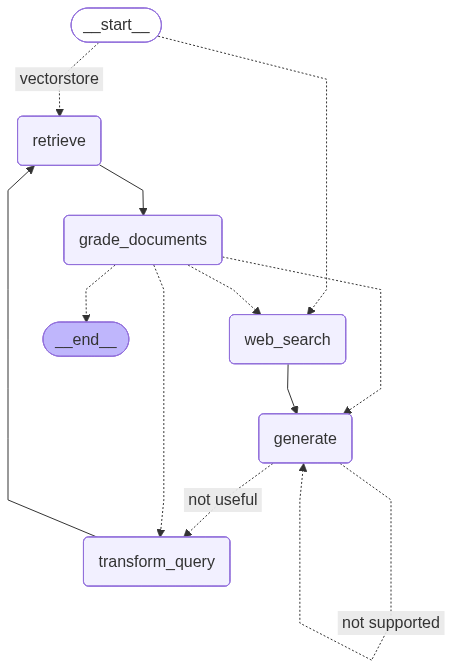

In [55]:
# Visualise the graph 
from IPython.display import Image, display

try:
    display(Image(adaptive_rag_app.get_graph(xray=True).draw_mermaid_png()))
except Exception as e:
    print(f"Graph visualisation skipped: {e}")

## 6. Run & Test

Stream the graph for a question and print the final answer.

In [56]:
from pprint import pprint

def ask(question: str) -> str:
    """Run the adaptive RAG pipeline and return the final answer."""
    print(f"\n{'='*60}")
    print(f"Question: {question}")
    print('='*60)

    final_output = None
    for output in adaptive_rag_app.stream({"question": question}):
        for node_name, node_value in output.items():
            print(f"  [Node: {node_name}]")
            final_output = node_value

    answer = final_output.get("generation", "No answer generated.")
    print(f"\nFinal Answer:\n{answer}")
    return answer

# Test queries 
_ = ask("What are the effects of masturbation?")


Question: What are the effects of masturbation?
---ROUTING QUESTION---
  → Vectorstore
---RETRIEVE FROM PINECONE---
  [Node: retrieve]
---GRADING DOCUMENT RELEVANCE---
  [-] Not relevant, filtered out
  [-] Not relevant, filtered out
  [-] Not relevant, filtered out
---DECIDING: GENERATE OR REWRITE?---
  → No relevant docs found, rewriting query (attempt 1)
  [Node: grade_documents]
---REWRITING QUERY---
  Rewritten: What are the physiological and psychological effects of self-induced orgasm?
  [Node: transform_query]
---RETRIEVE FROM PINECONE---
  [Node: retrieve]
---GRADING DOCUMENT RELEVANCE---
  [-] Not relevant, filtered out
  [-] Not relevant, filtered out
  [-] Not relevant, filtered out
---DECIDING: GENERATE OR REWRITE?---
  → No relevant docs found, rewriting query (attempt 2)
  [Node: grade_documents]
---REWRITING QUERY---
  Rewritten: What are the physiological and psychological effects of self-induced orgasm in humans?
  [Node: transform_query]
---RETRIEVE FROM PINECONE---

In [ ]:
# Test web search fallback 
_ = ask("top news today in tamilnadu?")


Question: top news today?
---ROUTING QUESTION---
  → Web search
---WEB SEARCH FALLBACK---
  [Node: web_search]
---GENERATE ANSWER---
  (attempt 1)
---GRADING GENERATION---
  → Useful answer ✅
  [Node: generate]

Final Answer:
The leading story today is a Palantir executive warning of an “undeclared emergency,” discussing Iran, new U.S. weapons and how to avoid a potential World III. Other major headlines cover tensions in the Strait of Hormuz and a court move to block Trump‑era tariffs. NASA’s Artemis II mission also made news as astronauts returned safely after a lunar flyby.
